In [24]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
from ultralytics import YOLO, SAM
from skimage.morphology import skeletonize
from skimage.graph import pixel_graph
from scipy.spatial.distance import euclidean
import matplotlib.patches as patches
import random
import os
from pathlib import Path
from scipy import ndimage
from skimage.graph import pixel_graph
from skimage.morphology import skeletonize

In [3]:
def load_depth_map(depth_path):
    """
    Load ZED depth map. ZED saves depth as:
    - .png  → 16-bit, values in mm
    - .npy  → float32, values in mm
    - .pfm  → float32, values in mm
    Resize to match 512×512 if needed.
    """
    if depth_path.endswith('.npy'):
        depth = np.load(depth_path)
    else:
        depth = cv2.imread(depth_path, cv2.IMREAD_ANYDEPTH).astype(np.float32)


    valid = depth[(depth > 0) & np.isfinite(depth)]

    print(f"  Depth raw stats:")
    print(f"    min={valid.min():.2f}, max={valid.max():.2f}, "
          f"mean={valid.mean():.2f}, median={np.median(valid):.2f}")
    # ── auto-detect scale ──────────────────────────────────────
    median_val = np.median(valid)

    if median_val < 10:
        # likely in metres → convert to mm
        print(f"    → Detected metres, converting ×1000")
        depth = depth * 1000
    elif median_val < 100:
        # likely in cm → convert to mm
        print(f"    → Detected centimetres, converting ×10")
        depth = depth * 10
    elif median_val > 50000:
        # already large — possibly micrometres?
        print(f"    ⚠️  Unusually large values — check sensor units")
    else:
        print(f"    → Assumed millimetres, no conversion")

    return depth

x=load_depth_map("HD720_SN15044540_14-44-20/justtiff/0019_f005840_depth_raw.tiff")

  Depth raw stats:
    min=0.18, max=0.39, mean=0.31, median=0.32
    → Detected metres, converting ×1000


In [10]:

# CONFIGURATION

IMAGE_PATH = "HD720_SN15044540_14-44-20/masked_image/left/0015_f004611_left_seed512.png"           # 1280×720 RGB image
DEPTH_PATH = "HD720_SN15044540_14-44-20/justtiff/0015_f004611_depth_raw.tiff"     # depth map same size (mm, float32)
YOLO_MODEL = "best.pt"

# Camera intrinsics (ZED calibration)``

fx=773.335
fy=773.59
cx=653.055
cy=354.457
k1=-0.0320652
k2=0.00802689
k3=0.0182561
k4=-0.0147054

K = np.array([[fx, 0, cx],
              [0, fy, cy],
              [0,  0,  1]], dtype=np.float64)
D = np.array([k1, k2, k3, k4], dtype=np.float64)

ORIG_W,    ORIG_H    = 1280, 720

In [6]:

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Load image & depth map
# ══════════════════════════════════════════════════════════════════════════════
print("── Step 1: Loading image and depth map ──")

image_orig = np.array(Image.open(IMAGE_PATH).convert("RGB"))  # (720, 1280, 3)

if DEPTH_PATH.endswith('.npy'):
    depth_orig = np.load(DEPTH_PATH).astype(np.float32)        # (720, 1280)
else:
    depth_orig = cv2.imread(DEPTH_PATH, cv2.IMREAD_ANYDEPTH).astype(np.float32)

assert depth_orig.shape[:2] == (ORIG_H, ORIG_W), \
    f"Depth map must be {ORIG_H}×{ORIG_W}, got {depth_orig.shape}"
depth_orig = depth_orig * 1000

print(f"  Image shape : {image_orig.shape}")
print(f"  Depth shape : {depth_orig.shape}")
print(f"  Depth range : {np.nanmin(depth_orig):.1f} – {np.nanmax(depth_orig):.1f} mm")


── Step 1: Loading image and depth map ──
  Image shape : (720, 1280, 3)
  Depth shape : (720, 1280, 1)
  Depth range : 166.5 – 383.9 mm


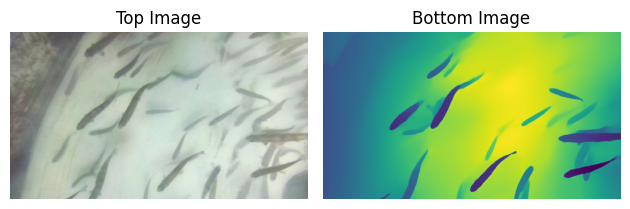

In [7]:
#Display original image and depth map

fig, (ax1, ax2) = plt.subplots(1, 2)

# 3. Display images in their respective subplots
ax1.imshow(image_orig)
ax1.set_title('Top Image')
ax1.axis('off')  # Optional: hide axes labels/ticks

ax2.imshow(depth_orig)
ax2.set_title('Bottom Image')
ax2.axis('off')

# 4. Display the final layout
plt.tight_layout() # Prevents titles from overlapping
plt.show()

In [11]:

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — YOLO detection on original 1280×720 image
# ══════════════════════════════════════════════════════════════════════════════
print("\n── Step 2: YOLO detection ──")

yolo = YOLO(YOLO_MODEL)
yolo_results = yolo(IMAGE_PATH, conf=0.5, imgsz=1280)

boxes_orig = yolo_results[0].boxes.xyxy.cpu().numpy()   # (N, 4) in 1280×720 space
print(f"  Detected {len(boxes_orig)} fish")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — SAM segmentation using YOLO boxes
# ══════════════════════════════════════════════════════════════════════════════
print("\n── Step 3: SAM segmentation ──")

sam = SAM("sam2_l.pt")
sam_results = sam(IMAGE_PATH, bboxes=boxes_orig)

masks_orig = sam_results[0].masks.data.cpu().numpy()    # (N, H, W) in original space
print(f"  Got {len(masks_orig)} masks, shape: {masks_orig[0].shape}")



── Step 2: YOLO detection ──


c:\Users\bekbe\ZED\objdet\.obj\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



image 1/1 c:\Users\bekbe\ZED\salmon_size\HD720_SN15044540_14-44-20\masked_image\left\0015_f004611_left_seed512.png: 736x1280 16 Salmons, 81.2ms
Speed: 9.1ms preprocess, 81.2ms inference, 22.9ms postprocess per image at shape (1, 3, 736, 1280)
  Detected 16 fish

── Step 3: SAM segmentation ──

image 1/1 c:\Users\bekbe\ZED\salmon_size\HD720_SN15044540_14-44-20\masked_image\left\0015_f004611_left_seed512.png: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 742.8ms
Speed: 20.1ms preprocess, 742.8ms inference, 31.9ms postprocess per image at shape (1, 3, 1024, 1024)
  Got 16 masks, shape: (720, 1280)


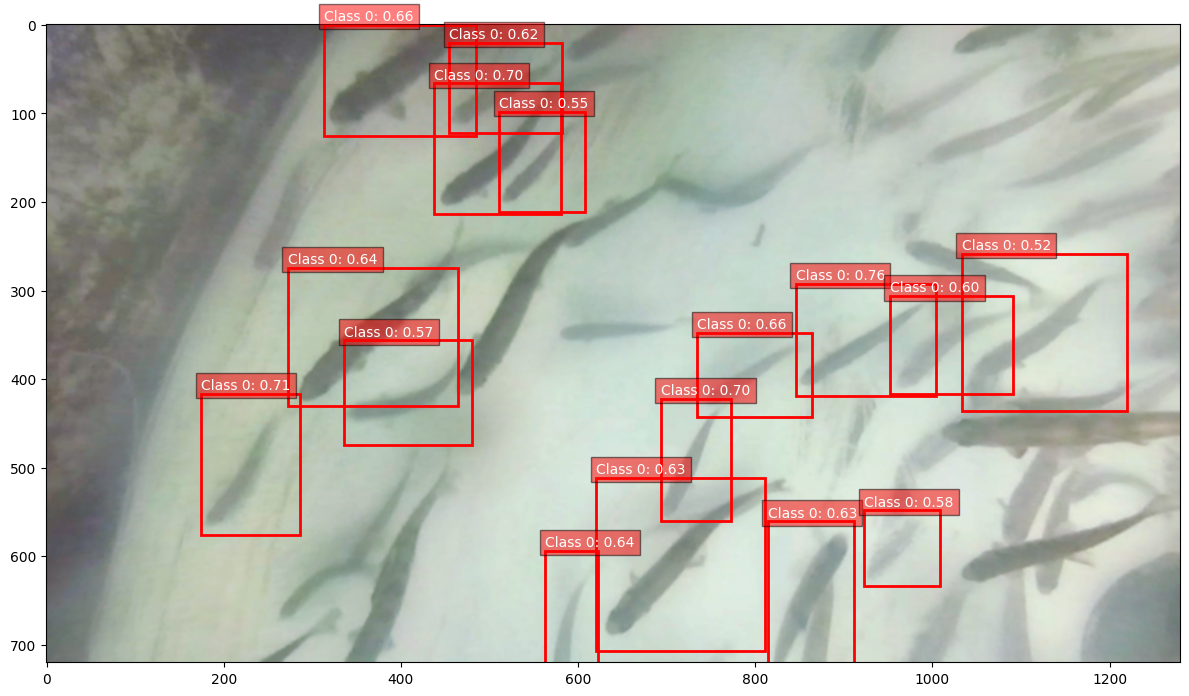

In [12]:
# VISUALIZATION: Show YOLO boxes before filtering boxes that are close to image borders 

image = Image.open(IMAGE_PATH)
fig, ax = plt.subplots(1, figsize=(12, 8))
ax.imshow(image)

for box in yolo_results[0].boxes:
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    conf = float(box.conf[0])
    cls = int(box.cls[0])
    
    width = x2 - x1
    height = y2 - y1
    
    rect = patches.Rectangle(
        (x1, y1), width, height,
        linewidth=2, edgecolor='red', facecolor='none'
    )
    ax.add_patch(rect)
    
    ax.text(
        x1, y1 - 5,
        f'Class {cls}: {conf:.2f}',
        bbox=dict(facecolor='red', alpha=0.5),
        fontsize=10, color='white'
    )

ax.axis('on')
plt.tight_layout()
plt.show()


image 1/1 c:\Users\bekbe\ZED\salmon_size\HD720_SN15044540_14-44-20\masked_image\left\0015_f004611_left_seed512.png: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1040.2ms
Speed: 14.0ms preprocess, 1040.2ms inference, 1.7ms postprocess per image at shape (1, 3, 1024, 1024)


c:\Users\bekbe\ZED\objdet\.obj\Lib\site-packages\ultralytics\models\sam\predict.py:318: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  bboxes = torch.as_tensor(bboxes, dtype=self.torch_dtype, device=self.device)


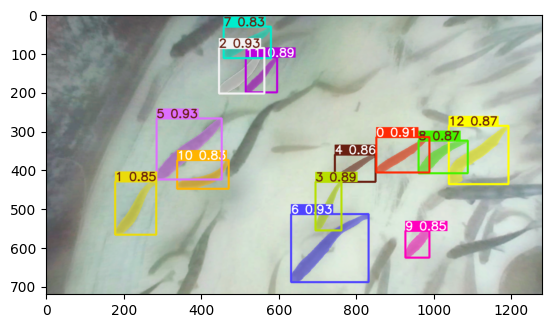

In [13]:
#Define a margin and cutoff boxes that are too close to the borders
image = cv2.imread(IMAGE_PATH)
h, w = image.shape[:2]

#Define a small margin (optional)
# Set to 0 if you only want to drop boxes touching the absolute edge
margin = 2 

def is_not_cutoff(box, img_w, img_h, m):
    x1, y1, x2, y2 = box[:4]
    # Returns True only if the box is NOT touching the borders
    return (x1 > m and y1 > m and x2 < (img_w - m) and y2 < (img_h - m))

#Filter  original boxes
# Assuming boxes_orig is a list or array of [x1, y1, x2, y2]
filtered_boxes = [box for box in boxes_orig if is_not_cutoff(box, w, h, margin)]

# Run SAM only on the safe boxes
sam_results = sam(IMAGE_PATH, bboxes=filtered_boxes)
#visualized final masks
annotated = sam_results[0].plot()  # returns BGR numpy array with masks drawn
plt.imshow(annotated)
masks_orig = sam_results[0].masks.data.cpu().numpy()    # (N, H, W) in original space

#boxes_orig[:, 0:2].shape

In [14]:

# ══════════════════════════════════════════════════════════════════════════════
# HELPER FUNCTIONS: Undistortion, back-projection, skeleton tracing, arc length calculation
# Used to go from 2D skeleton pixels → 3D points → arc length in mm
# applied during final length estimates from skeletonized masks
# ══════════════════════════════════════════════════════════════════════════════

def undistort_point(px, py):
    """Undistort a pixel coordinate using fisheye model."""
    point = np.array([[[float(px), float(py)]]], dtype=np.float32)
    undistorted = cv2.fisheye.undistortPoints(point, K, D, P=K)
    return undistorted[0][0]   # (x, y)


def pixel_to_3d(px, py, depth_map):
    """Back-project a pixel to 3D (mm) using depth map."""
    Z = depth_map[int(py), int(px)]
    if Z <= 0 or np.isnan(Z) or np.isinf(Z):
        return None
    x_u, y_u = undistort_point(px, py)
    X = (x_u - cx) * Z / fx
    Y = (y_u - cy) * Z / fy
    return np.array([X, Y, Z])


def trace_skeleton_path(skeleton):
    """Trace skeleton pixels from one endpoint to the other, returns ordered path."""
    def get_neighbors(skel, y, x):
        h, w = skel.shape
        return [(y+dy, x+dx)
                for dy in [-1,0,1] for dx in [-1,0,1]
                if not (dy==0 and dx==0)
                and 0<=y+dy<h and 0<=x+dx<w
                and skel[y+dy, x+dx]]

    points = np.argwhere(skeleton)
    if len(points) < 2:
        return []

    # Find endpoints (only 1 neighbor)
    endpoints = [(y,x) for y,x in points if len(get_neighbors(skeleton,y,x))==1]
    if len(endpoints) < 2:
        endpoints = [tuple(points[0]), tuple(points[-1])]

    start = endpoints[0]
    visited, path, current = {start}, [start], start

    while True:
        neighbors = [n for n in get_neighbors(skeleton, *current) if n not in visited]
        if not neighbors:
            break
        current = neighbors[0]
        visited.add(current)
        path.append(current)

    return path


In [15]:
# 3D arc length calculation: Sum Euclidean distances between consecutive 3D points along the skeleton path
# We have three versions:
# 1. arc_length_3d: Basic version using raw depth values at each pixel
# 2. arc_length_3d_1: Sanity check using straight-line pixel distance and median depth to estimate mm per pixel
# 3. arc_length_3d_smoothed: Uses a moving average to smooth depth noise before calculating distances

def arc_length_3d(path, depth_map):
    """Sum 3D Euclidean distances along skeleton path using depth map."""
    total_mm = 0.0
    valid    = 0

    for i in range(len(path) - 1):
        y0, x0 = path[i]
        y1, x1 = path[i+1]
        p0 = pixel_to_3d(x0, y0, depth_map)
        p1 = pixel_to_3d(x1, y1, depth_map)
        if p0 is not None and p1 is not None:
            total_mm += np.linalg.norm(p1 - p0)
            valid += 1

    return total_mm, valid

def arc_length_3d_1(depth_orig, skeleton_path, fx=772.985, expected_max_cm=20):
    """
    Estimate length using simple pixel size at median depth.
    Should match 3D arc length — if it doesn't, depth scale is wrong.
    """
    # median depth under the skeleton
    depths = [depth_orig[r, c] for r, c in skeleton_path]
    valid  = [z for z in depths if z > 0 and np.isfinite(z)]
    if not valid:
        print("No valid depth values!")
        return

    Z_median = np.median(valid)

    # pixel pitch at that depth (mm per pixel)
    mm_per_px = Z_median / fx

    # straight-line pixel distance head → tail
    r0, c0 = skeleton_path[0]
    r1, c1 = skeleton_path[-1]
    px_dist = np.sqrt((c1 - c0)**2 + (r1 - r0)**2)

    estimated_mm = px_dist * mm_per_px

    print(f"\n── Sanity check ──")
    print(f"  Median depth      : {Z_median:.1f} mm")
    print(f"  mm per pixel      : {mm_per_px:.3f}")
    print(f"  Pixel span (H→T)  : {px_dist:.1f} px")
    print(f"  Estimated length  : {estimated_mm:.1f} mm "
          f"({estimated_mm/10:.2f} cm)")

    if estimated_mm / 10 > expected_max_cm * 1.5:
        print(f"  Still too large — depth scale may still be wrong")
        print(f"  Expected Z range for {expected_max_cm}cm fish at this "
              f"distance: {Z_median:.0f}mm ± a few mm")
    else:
        print(f"Looks plausible")
    return estimated_mm, px_dist
def arc_length_3d_smoothed(path, depth_map, window_size=7):
    """
    Sum 3D distances using a moving average to filter depth noise.
    window_size: Number of points to average (must be odd, e.g., 3, 5, 7).
    """
    total_mm = 0.0
    coords_3d = []

    # Convert all valid path points to 3D first
    for y, x in path:
        p = pixel_to_3d(x, y, depth_map)
        if p is not None:
            coords_3d.append(p)
    if len(path) < 200:
        window_size-=2
    if len(coords_3d) < window_size:
        return 0.0, 0

    # Create a smoothed version of the 3D trajectory
    # We use a simple moving average for X, Y, and Z
    smoothed_path = []
    for i in range(len(coords_3d) - window_size + 1):
        window = coords_3d[i : i + window_size]
        avg_point = np.mean(window, axis=0)
        smoothed_path.append(avg_point)

    # Sum the distances of the smoothed segments
    for i in range(len(smoothed_path) - 1):
        p0 = smoothed_path[i]
        p1 = smoothed_path[i+1]
        total_mm += np.linalg.norm(p1 - p0)

    return total_mm, len(smoothed_path)


In [20]:
#Helper functions to analyze mask shape and skeleton for signs of two fish crossing/overlapping

def analyze_mask_shape(binary_mask):
    """Returns metrics that reveal if a mask contains 2 fish"""
    
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnt = max(contours, key=cv2.contourArea)
    
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    
    # 1. Solidity — ratio of contour area to convex hull area
    #    Single fish: ~0.85+  |  Two overlapping fish: much lower (concave notch)
    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area if hull_area > 0 else 0

    # 2. Circularity — single fish is elongated (low), merged blob is rounder (higher)
    circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0

    # 3. Aspect ratio from fitted ellipse
    if len(cnt) >= 5:
        (cx, cy), (MA, ma), angle = cv2.fitEllipse(cnt)
        aspect_ratio = MA / ma if ma > 0 else 1
    else:
        aspect_ratio = 1

    # 4. Convexity defects — deep notches = two fish crossing
    hull_indices = cv2.convexHull(cnt, returnPoints=False)
    defects = cv2.convexityDefects(cnt, hull_indices)
    
    max_defect_depth = 0
    significant_defects = 0
    if defects is not None:
        for i in range(defects.shape[0]):
            s, e, f, depth = defects[i, 0]
            depth_val = depth / 256.0  # convert to pixels
            if depth_val > max_defect_depth:
                max_defect_depth = depth_val
            if depth_val > 15:  # significant notch
                significant_defects += 1

    return {
        "solidity": solidity,
        "circularity": circularity,
        "aspect_ratio": aspect_ratio,
        "max_defect_depth": max_defect_depth,
        "significant_defects": significant_defects,
    }


def is_crossed_mask(metrics, 
                    solidity_thresh=0.80,
                    defect_thresh=20,
                    min_defects=1):
    """
    Returns True if the mask likely contains 2 overlapping fish
    """
    has_low_solidity   = metrics["solidity"] < solidity_thresh
    has_deep_defect    = metrics["max_defect_depth"] > defect_thresh
    has_many_defects   = metrics["significant_defects"] >= min_defects

    return has_low_solidity and (has_deep_defect or has_many_defects)

from skimage.morphology import skeletonize
import networkx as nx
from scipy.ndimage import label

def analyze_skeleton(binary_mask):
    """Detect branching in skeleton — a Y-fork means two fish crossed"""
    
    skeleton = skeletonize(binary_mask > 0)
    
    # Find all skeleton pixels
    skel_pixels = np.argwhere(skeleton)
    
    # Count neighbors for each skeleton pixel
    branch_points = []
    endpoints = []
    
    for (r, c) in skel_pixels:
        # 8-connected neighbors
        neighbors = skeleton[r-1:r+2, c-1:c+2].sum() - 1  # subtract self
        if neighbors >= 3:
            branch_points.append((r, c))  # Y-junction or cross
        elif neighbors == 1:
            endpoints.append((r, c))
    
    return {
        "n_branch_points": len(branch_points),
        "n_endpoints": len(endpoints),
        "branch_locations": branch_points,
        # Single fish: 0 branch points, 2 endpoints
        # Two crossed fish: 1+ branch points, 3-4 endpoints
    }


def is_crossed_skeleton(skel_metrics):
    """A clean single fish has 0 branch points and exactly 2 endpoints"""
    return skel_metrics["n_branch_points"] > 0 or skel_metrics["n_endpoints"] > 2
def check_fish_mask(binary_mask, verbose=True):
    
    shape_metrics  = analyze_mask_shape(binary_mask)
    skel_metrics   = analyze_skeleton(binary_mask)
    
    bad_shape    = is_crossed_mask(shape_metrics)
    bad_skeleton = is_crossed_skeleton(skel_metrics)
    
    status = " CROSSED / OVERLAPPING" if ( bad_shape or bad_skeleton ) else "SINGLE FISH"
    
    if verbose:
        print(f"Status: {status}")
        print(f"  Solidity:          {shape_metrics['solidity']:.3f}  (want > 0.80)")
        print(f"  Significant defects: {shape_metrics['significant_defects']}  (want 0)")
        print(f"  Max defect depth:  {shape_metrics['max_defect_depth']:.1f}px  (want < 20)")
        print(f"  Branch points:     {skel_metrics['n_branch_points']}  (want 0)")
        print(f"  Endpoints:         {skel_metrics['n_endpoints']}  (want 2)")
    
    return bad_shape or  bad_skeleton, shape_metrics, skel_metrics

2
Status: SINGLE FISH
  Solidity:          0.956  (want > 0.80)
  Significant defects: 0  (want 0)
  Max defect depth:  1.4px  (want < 20)
  Branch points:     0  (want 0)
  Endpoints:         2  (want 2)


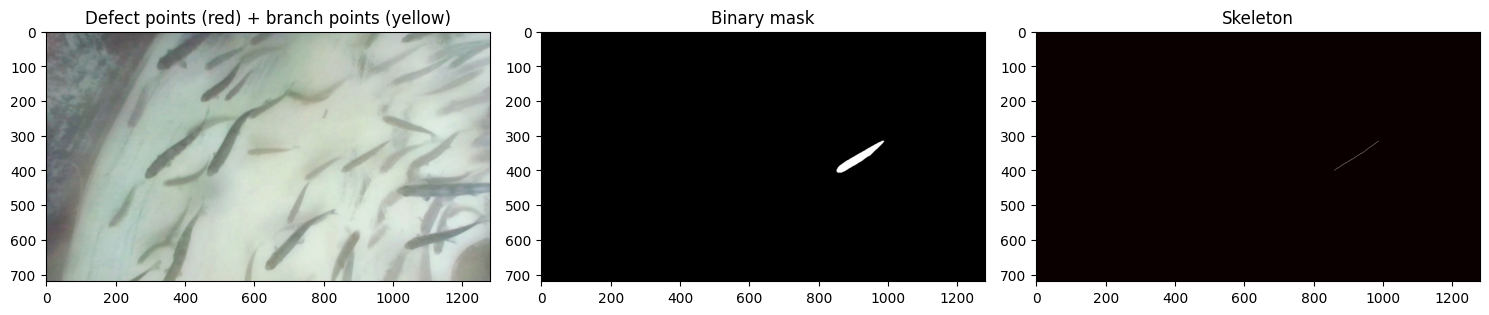

In [21]:
def visualize_cross_detection(image, binary_mask):
    binary_mask = (binary_mask > 0).astype(np.uint8)
    skeleton = skeletonize(binary_mask).astype(np.uint8)
    
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnt = max(contours, key=cv2.contourArea)
    hull_indices = cv2.convexHull(cnt, returnPoints=False)
    defects = cv2.convexityDefects(cnt, hull_indices)

    vis = image.copy()

    # Draw convexity defects (the notch where fish cross)
    if defects is not None:
        for i in range(defects.shape[0]):
            s, e, f, depth = defects[i, 0]
            if depth / 256.0 > 15:
                far_pt = tuple(cnt[f][0])
                cv2.circle(vis, far_pt, 8, (0, 0, 255), -1)  # red = defect notch

    # Mark skeleton branch points in yellow
    skel_metrics = analyze_skeleton(binary_mask)
    print (skel_metrics["n_endpoints"])
    for (r, c) in skel_metrics["branch_locations"]:
        cv2.circle(vis, (c, r), 6, (0, 255, 255), -1)  # yellow = branch
    check_fish_mask (binary_mask)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Defect points (red) + branch points (yellow)")
    axes[1].imshow(binary_mask, cmap='gray')
    axes[1].set_title("Binary mask")
    axes[2].imshow(skeleton, cmap='hot')
    axes[2].set_title("Skeleton")
    plt.tight_layout()
    plt.show()

visualize_cross_detection (image_orig, (masks_orig[0]>0.5).astype(np.uint8))


In [18]:


def keep_largest_blobs(binary_mask, min_area=None):
    """
    Removes small islands from a binary mask. 
    If min_area is None, it keeps only the single largest object.
    """
    # Ensure mask is 8-bit single channel
    binary_mask = binary_mask.astype(np.uint8)
    
    # 1. Find all connected components
    # num_labels: number of blobs found (including background)
    # labels: a map where each pixel has the ID of the blob it belongs to
    # stats: statistics for each blob (left, top, width, height, area)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)

    # If there's only 1 label, it's just the background (empty mask)
    if num_labels <= 1:
        return binary_mask

    # 2. Extract areas (the 4th column of the stats matrix)
    # We skip index 0 because that is the background area
    areas = stats[1:, cv2.CC_STAT_AREA]
    
    # 3. Determine our threshold
    if min_area is None:
        # Keep ONLY the single largest blob
        threshold = np.max(areas)
    else:
        # Keep blobs larger than the user-defined area
        threshold = min_area

    # 4. Create the output mask
    # We create a boolean mask where the area of the label is >= threshold
    # Then map it back to the label IDs
    new_mask = np.zeros_like(binary_mask)
    
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= threshold:
            new_mask[labels == i] = 255
            
    return new_mask


In [27]:

# ══════════════════════════════════════════════════════════════════════════════
# FINAL STEP: For each mask, skeletonize and calculate length in pixels and mm using depth map
# Skeletonize → pixel length → mm  (one fish at a time)
# ══════════════════════════════════════════════════════════════════════════════
print("\n──  Skeleton + measurement ──")
from scipy import ndimage
from scipy import ndimage
from skimage.graph import pixel_graph
from skimage.morphology import skeletonize
from skimage import morphology
results = []

for i, mask in enumerate(masks_orig):
    print(f"\n  Fish {i+1}/{len(masks_orig)}")
    binary = (mask > 0.5).astype(np.uint8)

    #check if mask overlaps, and there are 2 fish 
    shape_metrics  = analyze_mask_shape(binary)
    bad_shape    = is_crossed_mask(shape_metrics)
    skel_metrics   = analyze_skeleton(binary)
    bad_skeleton = is_crossed_skeleton(skel_metrics)


    blurred = cv2.GaussianBlur(binary.astype(np.float32) * 255, (7, 7), 2)
    binary = (blurred > 127).astype(np.uint8)

    #  Fill holes
    binary = ndimage.binary_fill_holes(binary).astype(np.uint8)
    binary = morphology.remove_small_objects(binary)
    binary= keep_largest_blobs (binary, 500 )
    #  Close then open with elliptical kernel
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN,  kernel, iterations=1)
 
    skeleton = skeletonize(binary)

    # Pixel arc length (in original image space)
    graph, nodes  = pixel_graph(skeleton, connectivity=2)
    length_px     = graph.sum() / 2
    print(f"    Pixel length : {length_px:.1f} px")

    #  Trace path and convert to mm using depth 
    path          = trace_skeleton_path(skeleton)
    length_mm, valid_steps =arc_length_3d_smoothed(path, depth_orig, window_size=11)
    print(f"    Real length  : {length_mm:.1f} mm  ({length_mm/10:.2f} cm)")
    print(f"    Valid depth steps: {valid_steps}/{len(path)-1}")
    if not bad_shape and not bad_skeleton and length_px >100:
        results.append({
            "fish_id":    i + 1,
            "mask":       binary,
            "skeleton":   skeleton,
            "path":       path,
            "length_px":  length_px,
            "length_mm":  length_mm,
            "box":        filtered_boxes[i],
        })



──  Skeleton + measurement ──

  Fish 1/13


c:\Users\bekbe\ZED\objdet\.obj\Lib\site-packages\skimage\_shared\utils.py:386: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  return func(*args, **kwargs)


    Pixel length : 162.8 px
    Real length  : 108.2 mm  (10.82 cm)
    Valid depth steps: 121/128

  Fish 2/13
    Pixel length : 168.2 px
    Real length  : 64.5 mm  (6.45 cm)
    Valid depth steps: 126/133

  Fish 3/13
    Pixel length : 155.9 px
    Real length  : 101.8 mm  (10.18 cm)
    Valid depth steps: 112/119

  Fish 4/13
    Pixel length : 138.4 px
    Real length  : 74.9 mm  (7.49 cm)
    Valid depth steps: 107/114

  Fish 5/13
    Pixel length : 118.9 px
    Real length  : 56.4 mm  (5.64 cm)
    Valid depth steps: 87/94

  Fish 6/13
    Pixel length : 218.3 px
    Real length  : 152.6 mm  (15.26 cm)
    Valid depth steps: 155/162

  Fish 7/13
    Pixel length : 257.6 px
    Real length  : 173.1 mm  (17.31 cm)
    Valid depth steps: 191/198

  Fish 8/13
    Pixel length : 133.5 px
    Real length  : 51.4 mm  (5.14 cm)
    Valid depth steps: 100/107

  Fish 9/13
    Pixel length : 147.8 px
    Real length  : 74.2 mm  (7.42 cm)
    Valid depth steps: 111/118

  Fish 10/13
   

In [28]:
# Print depth values under the skeleton to spot the problem
def sanity_check_depth(depth_orig, skeleton_path, fx, expected_max_cm=20):
    """
    Estimate length using simple pixel size at median depth.
    Should match 3D arc length — if it doesn't, depth scale is wrong.
    """
    # median depth under the skeleton
    depths = [depth_orig[r, c] for r, c in skeleton_path]
    valid  = [z for z in depths if z > 0 and np.isfinite(z)]
    if not valid:
        print("No valid depth values!")
        return

    Z_median = np.median(valid)

    # pixel pitch at that depth (mm per pixel)
    mm_per_px = Z_median / fx

    # straight-line pixel distance head → tail
    r0, c0 = skeleton_path[0]
    r1, c1 = skeleton_path[-1]
    px_dist = np.sqrt((c1 - c0)**2 + (r1 - r0)**2)

    estimated_mm = px_dist * mm_per_px

    print(f"\n── Sanity check ──")
    print(f"  Median depth      : {Z_median:.1f} mm")
    print(f"  mm per pixel      : {mm_per_px:.3f}")
    print(f"  Pixel span (H→T)  : {px_dist:.1f} px")
    print(f"  Estimated length  : {estimated_mm:.1f} mm "
          f"({estimated_mm/10:.2f} cm)")

    if estimated_mm / 10 > expected_max_cm * 1.5:
        print(f"  ⚠️  Still too large — depth scale may still be wrong")
        print(f"  Expected Z range for {expected_max_cm}cm fish at this "
              f"distance: {Z_median:.0f}mm ± a few mm")
    else:
        print(f"Looks plausible")
x= arc_length_3d(results[0]["path"], depth_orig)
print(x)
# Run before arc length:
sanity_check_depth(depth_orig, results[5]["path"], fx=772.985)

(np.float32(141.92357), 128)

── Sanity check ──
  Median depth      : 212.3 mm
  mm per pixel      : 0.275
  Pixel span (H→T)  : 210.9 px
  Estimated length  : 57.9 mm (5.79 cm)
Looks plausible



── Visualization ──


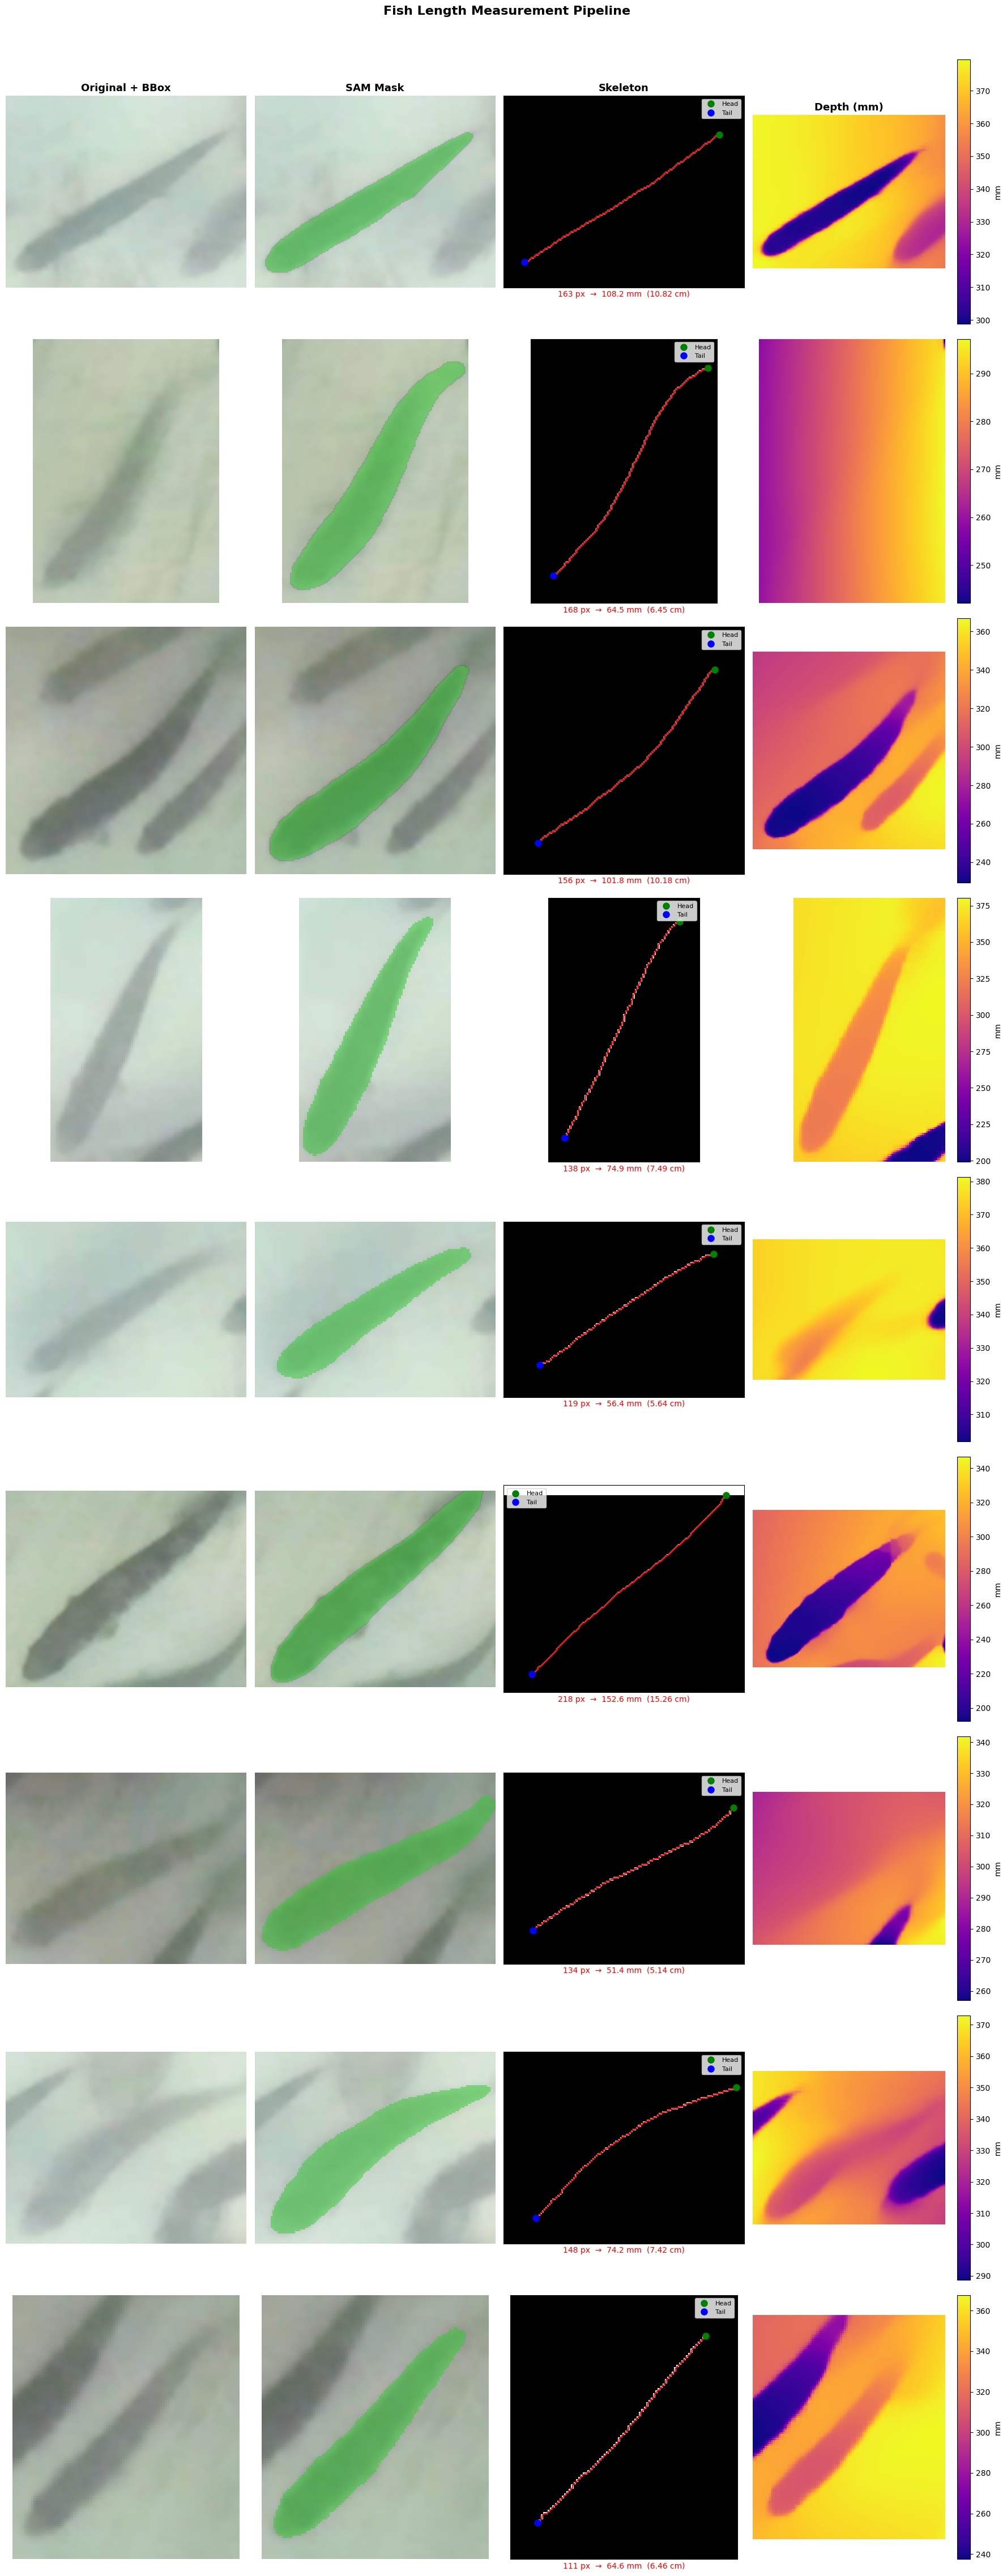

In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# VISUALIZATION — all fish in one figure
# ══════════════════════════════════════════════════════════════════════════════
print("\n── Visualization ──")

n = len(results)
fig, axes = plt.subplots(n, 4, figsize=(18, 5 * n))
if n == 1:
    axes = [axes]   # keep indexing consistent

col_titles = ["Original + BBox", "SAM Mask", "Skeleton", "Depth (mm)"]
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=13, fontweight='bold')

for row, r in enumerate(results):
    x1, y1, x2, y2 = map(int, r["box"])

    # Crop region for all panels
    img_crop   = image_orig[y1:y2, x1:x2]
    mask_crop  = r["mask"][y1:y2, x1:x2]
    skel_crop  = r["skeleton"][y1:y2, x1:x2]
    depth_crop = depth_orig[y1:y2, x1:x2]

    # Col 0 — original image + bounding box
    axes[row][0].imshow(img_crop)
    axes[row][0].set_ylabel(f"Fish {r['fish_id']}", fontsize=11)

    # Col 1 — SAM mask overlaid on image
    axes[row][1].imshow(img_crop)
    overlay = np.zeros((*mask_crop.shape, 4))
    overlay[mask_crop > 0] = [0.2, 0.8, 0.2, 0.5]
    axes[row][1].imshow(overlay)

    # Col 2 — skeleton + path endpoints
    axes[row][2].imshow(skel_crop, cmap='gray')
    if r["path"]:
        path_arr = np.array(r["path"])
        # Shift path coords to cropped space
        axes[row][2].plot(path_arr[:,1]-x1, path_arr[:,0]-y1, 'r-', linewidth=1.5)
        axes[row][2].plot(path_arr[0,1]-x1,  path_arr[0,0]-y1,  'go', markersize=8, label='Head')
        axes[row][2].plot(path_arr[-1,1]-x1, path_arr[-1,0]-y1, 'bo', markersize=8, label='Tail')
        axes[row][2].legend(fontsize=8)

    # Col 3 — depth map crop
    dm = axes[row][3].imshow(depth_crop, cmap='plasma')
    plt.colorbar(dm, ax=axes[row][3], label='mm')

    # Annotate length on skeleton panel
    axes[row][2].set_xlabel(
        f"{r['length_px']:.0f} px  →  {r['length_mm']:.1f} mm  ({r['length_mm']/10:.2f} cm)",
        fontsize=10, color='red'
    )

    for ax in axes[row]:
        ax.axis('off')
    axes[row][2].axis('on')
    axes[row][2].set_xticks([])
    axes[row][2].set_yticks([])

plt.suptitle("Fish Length Measurement Pipeline", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("fish_measurement_result.png", dpi=150, bbox_inches='tight')
plt.show()
# The end!

In [30]:

# ── Final summary ──────────────────────────────────────────────────────────────
print("\n══ RESULTS SUMMARY ══")
for r in results:
    print(f"  Fish {r['fish_id']}: {r['length_px']:.0f} px → {r['length_mm']:.1f} mm ({r['length_mm']/10:.2f} cm)")


══ RESULTS SUMMARY ══
  Fish 1: 163 px → 108.2 mm (10.82 cm)
  Fish 2: 168 px → 64.5 mm (6.45 cm)
  Fish 3: 156 px → 101.8 mm (10.18 cm)
  Fish 4: 138 px → 74.9 mm (7.49 cm)
  Fish 5: 119 px → 56.4 mm (5.64 cm)
  Fish 6: 218 px → 152.6 mm (15.26 cm)
  Fish 8: 134 px → 51.4 mm (5.14 cm)
  Fish 9: 148 px → 74.2 mm (7.42 cm)
  Fish 12: 111 px → 64.6 mm (6.46 cm)
